# 02 — Imagery Fetching
Loads the asset CSV from `01_sources.ipynb` and fetches a NAIP imagery tile centered on each asset centroid via Microsoft Planetary Computer.

**Input:** CSV from `../data/`  
**Output:** a list of `TileResult` objects ready for QC.

> ⚠️ **Before running:** set `INPUT_CSV` below to match the file you saved in notebook 01.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from imagery import ImageryFetcher, show_tiles

## Configuration

In [2]:
# !! SET THIS to the CSV you saved in 01_sources.ipynb
INPUT_CSV = '../data/maine_all_assets.csv'

# Buffer in meters around each asset centroid.
# 150m gives ~300m x 300m crop. Increase for larger assets.
BUFFER_M = 150

# Number of assets to sample per sector for visual inspection.
# Keeps fetch fast and ensures every asset type is represented.
# Increase once you are happy with the pipeline.
TILES_PER_SECTOR = 3

## Load assets from CSV

In [3]:
df = pd.read_csv(INPUT_CSV)
print(f'Loaded {len(df)} assets from {INPUT_CSV}')
print()
print(df['asset_type'].value_counts().to_string())

Loaded 2202 assets from ../data/maine_all_assets.csv

asset_type
telecom_tower              1210
power_substation            531
transport_airport           234
water_treatment             202
transport_train_station      25


## Sample assets per sector
Rather than fetching everything (which over-represents substations),
we sample `TILES_PER_SECTOR` assets from each sector.
The full dataset stays in `df` -- `df_sample` is only used for tile fetching.

In [4]:
df_sample = (
    df.groupby('asset_type', group_keys=False)
      .apply(lambda g: g.sample(min(len(g), TILES_PER_SECTOR), random_state=42))
      .reset_index(drop=True)
)

print('Sampled assets per sector:')
print(df_sample['asset_type'].value_counts().to_string())
print(f'\nTotal tiles to fetch: {len(df_sample)}')

Sampled assets per sector:
asset_type
power_substation           3
telecom_tower              3
transport_airport          3
transport_train_station    3
water_treatment            3

Total tiles to fetch: 15


C:\Users\guthrie.j\AppData\Local\Temp\ipykernel_31708\3486759874.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), TILES_PER_SECTOR), random_state=42))


## Fetch imagery tiles

In [5]:
fetcher = ImageryFetcher(buffer_m=BUFFER_M)
results = fetcher.fetch_all(df_sample)

  [10/15] ok=6  failed=4
  [15/15] ok=9  failed=6


## Summary table

In [6]:
summary = fetcher.summarize(results)
summary[['asset_type','image_date','status','has_image','image_shape','error_msg']]

,asset_type,image_date,status,has_image,image_shape,error_msg
0,power_substation,2023-08-10,ok,True,"(3, 1001, 1004)",
1,power_substation,None,no_scene,False,,No NAIP scene found for this location/date range.
2,power_substation,2023-09-07,ok,True,"(3, 1013, 1016)",
3,telecom_tower,2023-08-23,ok,True,"(3, 1020, 1023)",
4,telecom_tower,None,no_scene,False,,No NAIP scene found for this location/date range.
5,telecom_tower,None,no_scene,False,,No NAIP scene found for this location/date range.
6,transport_airport,2023-11-06,ok,True,"(3, 1012, 886)",
7,transport_airport,2023-07-12,ok,True,"(3, 1021, 1025)",
8,transport_airport,None,no_scene,False,,No NAIP scene found for this location/date range.
9,transport_train_station,2023-08-23,ok,True,"(3, 1021, 1024)",


## Visual inspection -- tiles by sector
One grid per asset type so you can sanity check each independently.
Ask: does this tile actually show the right kind of infrastructure?


--- power_substation ---


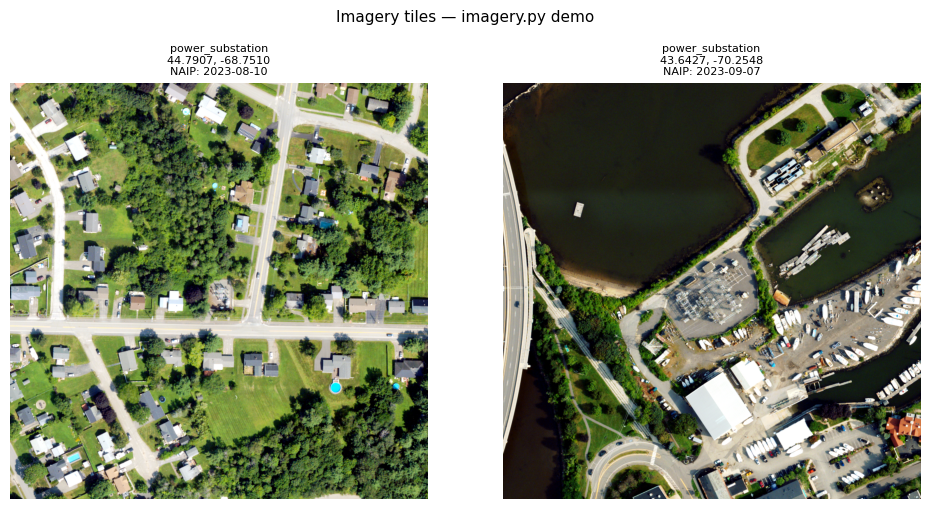

Tile grid saved to tile_preview.png

--- telecom_tower ---


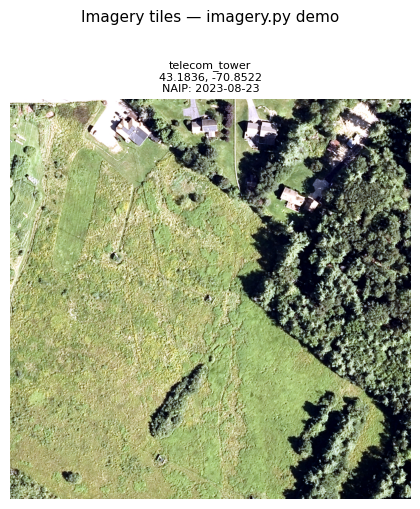

Tile grid saved to tile_preview.png

--- transport_airport ---


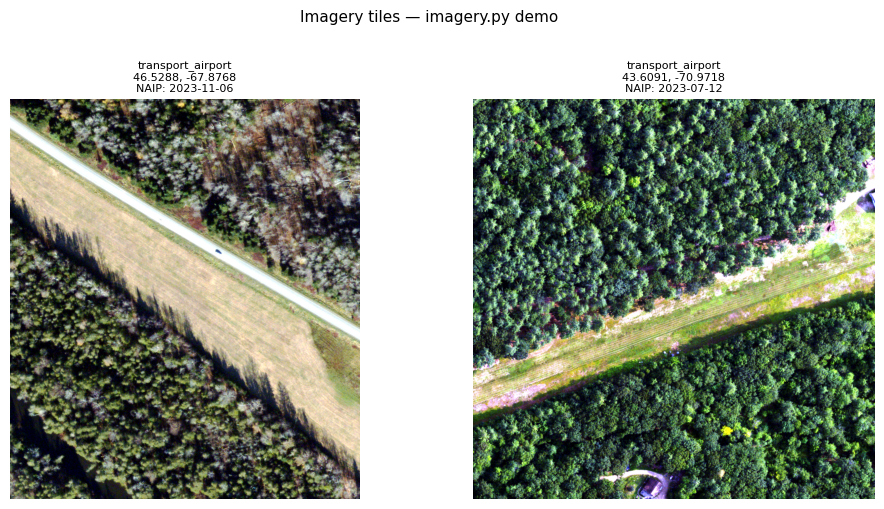

Tile grid saved to tile_preview.png

--- transport_train_station ---


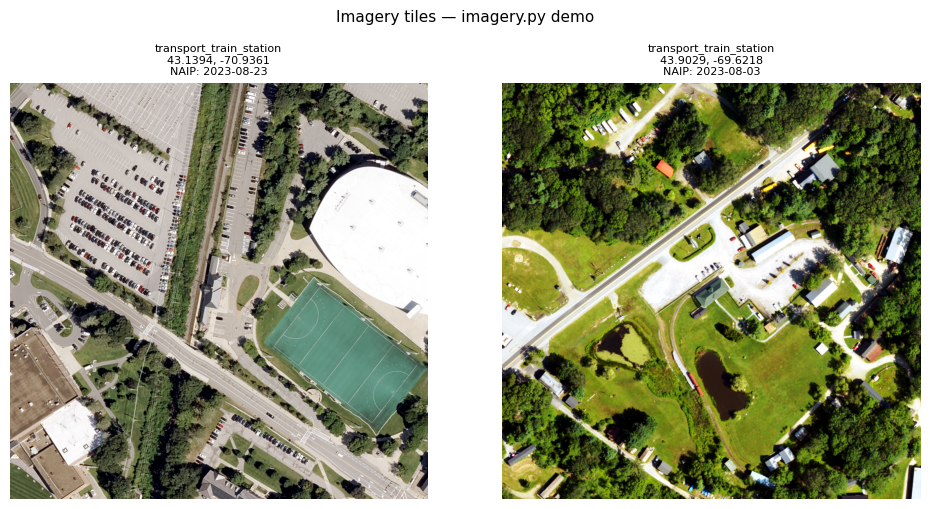

Tile grid saved to tile_preview.png

--- water_treatment ---


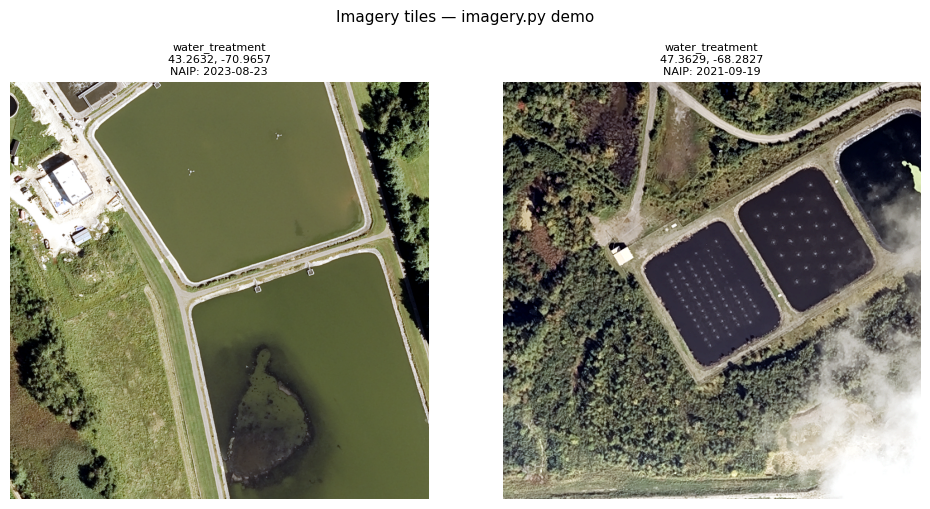

Tile grid saved to tile_preview.png


In [7]:
sector_results = {}
for asset_type in df_sample['asset_type'].unique():
    sector_results[asset_type] = [
        r for r in results if r.asset_type == asset_type
    ]

for asset_type, tiles in sector_results.items():
    print(f'\n--- {asset_type} ---')
    show_tiles(tiles, max_show=TILES_PER_SECTOR)

## Status breakdown

In [8]:
print('Status counts:')
print(summary['status'].value_counts().to_string())
print()
# show any failures for investigation
failures = summary[summary['status'] != 'ok']
if failures.empty:
    print('All tiles fetched successfully.')
else:
    print(f'{len(failures)} failed tiles:')
    print(failures[['asset_id','asset_type','status','error_msg']].to_string(index=False))

Status counts:
status
ok          9
no_scene    6

6 failed tiles:
           asset_id              asset_type   status                                         error_msg
osm_node_1199283038        power_substation no_scene No NAIP scene found for this location/date range.
osm_node_5611980351           telecom_tower no_scene No NAIP scene found for this location/date range.
osm_node_4411803715           telecom_tower no_scene No NAIP scene found for this location/date range.
  osm_way_136585950       transport_airport no_scene No NAIP scene found for this location/date range.
osm_node_1209344677 transport_train_station no_scene No NAIP scene found for this location/date range.
  osm_way_694601363         water_treatment no_scene No NAIP scene found for this location/date range.
